# Analysis Setup

In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

rm_files = list(
    Path(
        "../data/PoTeC/precomputed_reading_measures/reading_measures_merged"
    ).glob("*.tsv")
)

print("Number of files:", len(rm_files))

Number of files: 900


In [221]:
for i, file in enumerate(rm_files):
    print(i, file.name)

0 reader70_p3_merged.tsv
1 reader65_b1_merged.tsv
2 reader79_p1_merged.tsv
3 reader8_p4_merged.tsv
4 reader66_p0_merged.tsv
5 reader73_b2_merged.tsv
6 reader71_p0_merged.tsv
7 reader0_p5_merged.tsv
8 reader64_b2_merged.tsv
9 reader78_p2_merged.tsv
10 reader67_p3_merged.tsv
11 reader3_b4_merged.tsv
12 reader40_b5_merged.tsv
13 reader72_b1_merged.tsv
14 reader72_p5_merged.tsv
15 reader40_p1_merged.tsv
16 reader3_p0_merged.tsv
17 reader0_b1_merged.tsv
18 reader71_b4_merged.tsv
19 reader41_p2_merged.tsv
20 reader66_b4_merged.tsv
21 reader2_p3_merged.tsv
22 reader8_b0_merged.tsv
23 reader79_b5_merged.tsv
24 reader1_b2_merged.tsv
25 reader65_p5_merged.tsv
26 reader7_b4_merged.tsv
27 reader63_p3_merged.tsv
28 reader76_b1_merged.tsv
29 reader69_b0_merged.tsv
30 reader75_p0_merged.tsv
31 reader60_b2_merged.tsv
32 reader4_p5_merged.tsv
33 reader62_p0_merged.tsv
34 reader77_b2_merged.tsv
35 reader68_b3_merged.tsv
36 reader74_p3_merged.tsv
37 reader61_b1_merged.tsv
38 reader61_p5_merged.tsv
39 rea

In [222]:
# Inspect the first reading-measure file
sample_file = rm_files[0]

sample_df = pd.read_csv(sample_file, sep="\t")

print("Sample file:", sample_file.name)
print("Shape:", sample_df.shape)

sample_df.head()

Sample file: reader70_p3_merged.tsv
Shape: (176, 106)


,word,word_with_punct,word_index_in_text,word_index_in_sent,sent_index_in_text,text_id_numeric,text_domain,word_length,STTS_punctuation_before,STTS_punctuation_after,...,text_domain_numeric,trial,text_id,reader_id,gender_numeric,reader_discipline_numeric,age,level_of_studies_numeric,discipline_level_of_studies_numeric,expert_reading_label_numeric
0,Der,Der,1,1,1,9,physics,3,0,0,...,1,2,p3,70,1.0,0,25.0,1,1,0
1,entscheidende,entscheidende,2,2,1,9,physics,13,0,0,...,1,2,p3,70,1.0,0,25.0,1,1,0
2,Durchbruch,Durchbruch,3,3,1,9,physics,10,0,0,...,1,2,p3,70,1.0,0,25.0,1,1,0
3,zur,zur,4,4,1,9,physics,3,0,0,...,1,2,p3,70,1.0,0,25.0,1,1,0
4,Aufstellung,Aufstellung,5,5,1,9,physics,11,0,0,...,1,2,p3,70,1.0,0,25.0,1,1,0


In [223]:
print("Columns:")
for col in sample_df.columns:
    print(col)

Columns:
word
word_with_punct
word_index_in_text
word_index_in_sent
sent_index_in_text
text_id_numeric
text_domain
word_length
STTS_punctuation_before
STTS_punctuation_after
is_in_quote
is_in_parentheses
is_clause_beginning
is_sent_beginning
is_clause_end
is_sent_end
is_abbreviation
is_expert_technical_term
is_general_technical_term
contains_symbol
contains_hyphen
contains_abbreviation
STTS_PoS_tag
type
type_length_chars
PoS_tag
lemma
lemma_length_chars
syllables
type_length_syllables
annotated_type_frequency_normalized
type_frequency_normalized
lemma_frequency_normalized
familiarity_normalized
regularity_normalized
document_frequency_normalized
sentence_frequency_normalized
cumulative_syllable_corpus_frequency_normalized
cumulative_syllable_lexicon_frequency_normalized
cumulative_character_corpus_frequency_normalized
cumulative_character_lexicon_frequency_normalized
cumulative_character_bigram_corpus_frequency_normalized
cumulative_character_bigram_lexicon_frequency_normalized
cumulat

## Selecting variables for the project



In [224]:
# Load and concatenate all reading-measure files
dfs = []

for file in rm_files:
    df_tmp = pd.read_csv(file, sep="\t")
    df_tmp["source_file"] = file.name
    dfs.append(df_tmp)

reading_df = pd.concat(dfs, ignore_index=True)

print("Combined reading dataframe shape:", reading_df.shape)
print("Number of source files:", reading_df["source_file"].nunique())

reading_df.head()

Combined reading dataframe shape: (142125, 107)
Number of source files: 900


,word,word_with_punct,word_index_in_text,word_index_in_sent,sent_index_in_text,text_id_numeric,text_domain,word_length,STTS_punctuation_before,STTS_punctuation_after,...,trial,text_id,reader_id,gender_numeric,reader_discipline_numeric,age,level_of_studies_numeric,discipline_level_of_studies_numeric,expert_reading_label_numeric,source_file
0,Der,Der,1,1,1,9,physics,3,0,0,...,2,p3,70,1.0,0,25.0,1,1,0,reader70_p3_merged.tsv
1,entscheidende,entscheidende,2,2,1,9,physics,13,0,0,...,2,p3,70,1.0,0,25.0,1,1,0,reader70_p3_merged.tsv
2,Durchbruch,Durchbruch,3,3,1,9,physics,10,0,0,...,2,p3,70,1.0,0,25.0,1,1,0,reader70_p3_merged.tsv
3,zur,zur,4,4,1,9,physics,3,0,0,...,2,p3,70,1.0,0,25.0,1,1,0,reader70_p3_merged.tsv
4,Aufstellung,Aufstellung,5,5,1,9,physics,11,0,0,...,2,p3,70,1.0,0,25.0,1,1,0,reader70_p3_merged.tsv


In [225]:
# Text-level surprisal estimates provided in PoTeC
surprisal_cols = [
    "text_surprisal_gpt2-base",
    "text_surprisal_gpt2-large",
    "text_surprisal_llama-7b",
    "text_surprisal_llama-13b",
    "text_surprisal_bert-base"
]

# Check that all surprisal columns exist
missing_surprisal_cols = [col for col in surprisal_cols if col not in reading_df.columns]
print("Missing surprisal columns:", missing_surprisal_cols)

# Create averaged text-level surprisal
reading_df["mean_text_surprisal"] = reading_df[surprisal_cols].mean(axis=1, skipna=True)

reading_df[["word"] + surprisal_cols + ["mean_text_surprisal"]].head()

Missing surprisal columns: []


,word,text_surprisal_gpt2-base,text_surprisal_gpt2-large,text_surprisal_llama-7b,text_surprisal_llama-13b,text_surprisal_bert-base,mean_text_surprisal
0,Der,3.357862,3.437057,15.763550,15.390879,0.002877,7.590445
1,entscheidende,8.724937,8.580069,9.567480,9.752765,1.086493,7.542349
2,Durchbruch,4.796450,4.861759,5.670253,3.328325,1.802679,4.091893
3,zur,4.732331,3.804068,1.049403,0.712943,0.082160,2.076181
4,Aufstellung,9.540144,9.919480,9.013192,9.330481,4.885766,8.537813


In [226]:
# Main eye-movement measures
measures = [
    "FFD",
    "FPRT",
    "TFT",
    "TFC",
    "RRT",
    "RPD_exc",
    "TRC_out"
]

# Word-level controls for the difficulty-adjusted analysis
controls = [
    "word_length",
    "lemma_frequency_normalized",
    "mean_text_surprisal"
]

# Variables needed for grouping and interpretation
metadata_cols = [
    "reader_id",
    "text_id",
    "trial",
    "word",
    "word_index_in_text",
    "text_domain",
    "text_domain_numeric",
    "reader_discipline_numeric",
    "level_of_studies_numeric",
    "expert_reading_label_numeric",
    "is_expert_technical_term",
    "is_general_technical_term"
]

selected_cols = metadata_cols + controls + measures

analysis_df = reading_df[selected_cols].copy()

print("Analysis dataframe shape:", analysis_df.shape)
analysis_df.head()

Analysis dataframe shape: (142125, 22)


,reader_id,text_id,trial,word,word_index_in_text,text_domain,text_domain_numeric,reader_discipline_numeric,level_of_studies_numeric,expert_reading_label_numeric,...,word_length,lemma_frequency_normalized,mean_text_surprisal,FFD,FPRT,TFT,TFC,RRT,RPD_exc,TRC_out
0,70,p3,2,Der,1,physics,1,0,1,0,...,3,80100.306911,7.590445,270,270,481,2,211,0,0
1,70,p3,2,entscheidende,2,physics,1,0,1,0,...,13,80.164825,7.542349,78,626,2295,11,1669,211,1
2,70,p3,2,Durchbruch,3,physics,1,0,1,0,...,10,9.017112,4.091893,231,231,616,3,385,0,0
3,70,p3,2,zur,4,physics,1,0,1,0,...,3,1790.595728,2.076181,215,215,569,2,354,0,1
4,70,p3,2,Aufstellung,5,physics,1,0,1,0,...,11,20.756526,8.537813,244,244,881,4,637,0,0


## Inspecting the coding of participant and text variables


In [227]:
coding_cols = [
    "text_domain",
    "text_domain_numeric",
    "reader_discipline_numeric",
    "level_of_studies_numeric",
    "expert_reading_label_numeric"
]

for col in coding_cols:
    print("\n" + col)
    print(analysis_df[col].value_counts(dropna=False).sort_index())


text_domain
text_domain
biology    71550
physics    70575
Name: count, dtype: int64

text_domain_numeric
text_domain_numeric
0    71550
1    70575
Name: count, dtype: int64

reader_discipline_numeric
reader_discipline_numeric
0    81485
1    60640
Name: count, dtype: int64

level_of_studies_numeric
level_of_studies_numeric
0    53060
1    89065
Name: count, dtype: int64

expert_reading_label_numeric
expert_reading_label_numeric
0    97547
1    44578
Name: count, dtype: int64


In [228]:
# Mapping between text_domain and text_domain_numeric
text_domain_mapping = (
    analysis_df[["text_domain", "text_domain_numeric"]]
    .drop_duplicates()
    .sort_values(["text_domain_numeric", "text_domain"])
)

text_domain_mapping

,text_domain,text_domain_numeric
176,biology,0
0,physics,1


In [229]:
diagnostic = (
    analysis_df
    .groupby([
        "reader_id",
        "reader_discipline_numeric",
        "level_of_studies_numeric",
        "text_domain",
        "text_domain_numeric",
        "expert_reading_label_numeric"
    ])
    .size()
    .reset_index(name="n_rows")
)

diagnostic.head(20)

,reader_id,reader_discipline_numeric,level_of_studies_numeric,text_domain,text_domain_numeric,expert_reading_label_numeric,n_rows
0,0,1,1,biology,0,0,954
1,0,1,1,physics,1,1,941
2,1,1,1,biology,0,0,954
3,1,1,1,physics,1,1,941
4,2,1,1,biology,0,0,954
5,2,1,1,physics,1,1,941
6,3,1,1,biology,0,0,954
7,3,1,1,physics,1,1,941
8,4,1,1,biology,0,0,954
9,4,1,1,physics,1,1,941


In [230]:
diagnostic_summary = (
    diagnostic
    .groupby([
        "reader_discipline_numeric",
        "level_of_studies_numeric",
        "text_domain",
        "text_domain_numeric",
        "expert_reading_label_numeric"
    ])
    ["reader_id"]
    .nunique()
    .reset_index(name="n_readers")
    .sort_values([
        "reader_discipline_numeric",
        "level_of_studies_numeric",
        "text_domain_numeric",
        "expert_reading_label_numeric"
    ])
)

diagnostic_summary

,reader_discipline_numeric,level_of_studies_numeric,text_domain,text_domain_numeric,expert_reading_label_numeric,n_readers
0,0,0,biology,0,0,16
1,0,0,physics,1,0,16
2,0,1,biology,0,1,27
3,0,1,physics,1,0,27
4,1,0,biology,0,0,12
5,1,0,physics,1,0,12
6,1,1,biology,0,0,20
7,1,1,physics,1,1,20


## Defining the four reading classes

The numeric coding is:
- `text_domain_numeric`: 0 = biology, 1 = physics
- `reader_discipline_numeric`: 0 = biology, 1 = physics
- `level_of_studies_numeric`: 0 = undergraduate, 1 = graduate

Using these variables, we define four reading classes:
1. Expert: graduate reader reading in their own discipline.
2. Graduate out-of-domain: graduate reader reading in the other discipline.
3. Undergraduate in-domain: undergraduate reader reading in their own discipline.
4. Undergraduate out-of-domain: undergraduate reader reading in the other discipline.

In [231]:
def assign_reading_class(row):
    same_domain = row["reader_discipline_numeric"] == row["text_domain_numeric"]
    is_graduate = row["level_of_studies_numeric"] == 1

    if is_graduate and same_domain:
        return "Expert"
    elif is_graduate and not same_domain:
        return "Graduate out-of-domain"
    elif (not is_graduate) and same_domain:
        return "Undergraduate in-domain"
    else:
        return "Undergraduate out-of-domain"


analysis_df["reading_class"] = analysis_df.apply(assign_reading_class, axis=1)

class_order = [
    "Expert",
    "Graduate out-of-domain",
    "Undergraduate in-domain",
    "Undergraduate out-of-domain"
]

analysis_df["reading_class"] = pd.Categorical(
    analysis_df["reading_class"],
    categories=class_order,
    ordered=True
)

analysis_df[[
    "reader_id",
    "reader_discipline_numeric",
    "level_of_studies_numeric",
    "text_domain",
    "text_domain_numeric",
    "expert_reading_label_numeric",
    "reading_class"
]].drop_duplicates().head(20)

,reader_id,reader_discipline_numeric,level_of_studies_numeric,text_domain,text_domain_numeric,expert_reading_label_numeric,reading_class
0,70,0,1,physics,1,0,Graduate out-of-domain
176,65,0,1,biology,0,1,Expert
338,79,0,1,physics,1,0,Graduate out-of-domain
490,8,1,1,physics,1,1,Expert
631,66,0,1,physics,1,0,Graduate out-of-domain
807,73,0,1,biology,0,1,Expert
957,71,0,1,physics,1,0,Graduate out-of-domain
1133,0,1,1,physics,1,1,Expert
1303,64,0,1,biology,0,1,Expert
1453,78,0,1,physics,1,0,Graduate out-of-domain


In [232]:
check_expert_label = (
    analysis_df
    .groupby(["reading_class", "expert_reading_label_numeric"], observed=True)
    .size()
    .reset_index(name="n_rows")
)

check_expert_label

,reading_class,expert_reading_label_numeric,n_rows
0,Expert,1,44578
1,Graduate out-of-domain,0,44487
2,Undergraduate in-domain,0,26556
3,Undergraduate out-of-domain,0,26504


In [233]:
class_counts_words = (
    analysis_df["reading_class"]
    .value_counts()
    .reindex(class_order)
)

class_counts_words

reading_class
Expert                         44578
Graduate out-of-domain         44487
Undergraduate in-domain        26556
Undergraduate out-of-domain    26504
Name: count, dtype: int64

In [234]:
class_counts_readers = (
    analysis_df
    .groupby("reading_class", observed=True)["reader_id"]
    .nunique()
    .reindex(class_order)
)

class_counts_readers

reading_class
Expert                         47
Graduate out-of-domain         47
Undergraduate in-domain        28
Undergraduate out-of-domain    28
Name: reader_id, dtype: int64

In [235]:
# Check how the four reading classes are built from discipline, level, and text domain

class_validation = (
    analysis_df
    .groupby([
        "reader_discipline_numeric",
        "level_of_studies_numeric",
        "text_domain",
        "reading_class"
    ], observed=True)
    .agg(
        n_readers=("reader_id", "nunique"),
        n_rows=("word", "size")
    )
    .reset_index()
    .sort_values([
        "level_of_studies_numeric",
        "reader_discipline_numeric",
        "text_domain"
    ])
)

class_validation

,reader_discipline_numeric,level_of_studies_numeric,text_domain,reading_class,n_readers,n_rows
0,0,0,biology,Undergraduate in-domain,16,15264
1,0,0,physics,Undergraduate out-of-domain,16,15056
4,1,0,biology,Undergraduate out-of-domain,12,11448
5,1,0,physics,Undergraduate in-domain,12,11292
2,0,1,biology,Expert,27,25758
3,0,1,physics,Graduate out-of-domain,27,25407
6,1,1,biology,Graduate out-of-domain,20,19080
7,1,1,physics,Expert,20,18820


In [236]:
# Add readable labels for interpretation

discipline_map = {
    0: "Biology reader",
    1: "Physics reader"
}

level_map = {
    0: "Undergraduate",
    1: "Graduate"
}

class_validation["reader_discipline"] = class_validation["reader_discipline_numeric"].map(discipline_map)
class_validation["level_of_studies"] = class_validation["level_of_studies_numeric"].map(level_map)

class_validation = class_validation[
    [
        "reader_discipline",
        "level_of_studies",
        "text_domain",
        "reading_class",
        "n_readers",
        "n_rows"
    ]
]

class_validation

,reader_discipline,level_of_studies,text_domain,reading_class,n_readers,n_rows
0,Biology reader,Undergraduate,biology,Undergraduate in-domain,16,15264
1,Biology reader,Undergraduate,physics,Undergraduate out-of-domain,16,15056
4,Physics reader,Undergraduate,biology,Undergraduate out-of-domain,12,11448
5,Physics reader,Undergraduate,physics,Undergraduate in-domain,12,11292
2,Biology reader,Graduate,biology,Expert,27,25758
3,Biology reader,Graduate,physics,Graduate out-of-domain,27,25407
6,Physics reader,Graduate,biology,Graduate out-of-domain,20,19080
7,Physics reader,Graduate,physics,Expert,20,18820


This table validates the construction of the four reading classes. Graduate readers are classified as Expert when the text domain matches their discipline and as Graduate out-of-domain otherwise. Undergraduate readers are classified as Undergraduate in-domain when the text domain matches their discipline and as Undergraduate out-of-domain otherwise.

## Cleaning the seven eye-movement measures


In [237]:
missing_measures = (
    analysis_df[measures]
    .isna()
    .sum()
    .to_frame("n_missing")
)

missing_measures["missing_percent"] = (
    100 * missing_measures["n_missing"] / len(analysis_df)
).round(2)

missing_measures

,n_missing,missing_percent
FFD,0,0.0
FPRT,0,0.0
TFT,0,0.0
TFC,0,0.0
RRT,0,0.0
RPD_exc,0,0.0
TRC_out,0,0.0


In [238]:
missing_controls = (
    analysis_df[controls]
    .isna()
    .sum()
    .to_frame("n_missing")
)

missing_controls["missing_percent"] = (
    100 * missing_controls["n_missing"] / len(analysis_df)
).round(2)

missing_controls

,n_missing,missing_percent
word_length,0,0.0
lemma_frequency_normalized,0,0.0
mean_text_surprisal,0,0.0


# Raw eye-movement measures by reading class



In [239]:


# Raw means table
raw_means = (
    analysis_df
    .groupby("reading_class", observed=True)[measures]
    .mean()
    .reindex(class_order)
)

# Rename columns with units for the report
measure_labels_with_units = {
    "FFD": "FFD (ms)",
    "FPRT": "FPRT (ms)",
    "TFT": "TFT (ms)",
    "TFC": "TFC (count)",
    "RRT": "RRT (ms)",
    "RPD_exc": "RPD_exc (ms)",
    "TRC_out": "TRC_out (count)"
}

table2_raw = (
    raw_means
    .rename(columns=measure_labels_with_units)
    .round(1)
)

table2_raw

,FFD (ms),FPRT (ms),TFT (ms),TFC (count),RRT (ms),RPD_exc (ms),TRC_out (count)
reading_class,,,,,,,
Expert,164.9,238.4,566.2,2.5,327.8,288.4,0.4
Graduate out-of-domain,170.0,259.6,696.4,3.1,436.8,389.9,0.4
Undergraduate in-domain,164.3,241.0,606.3,2.8,365.3,324.1,0.4
Undergraduate out-of-domain,165.1,247.2,664.7,3.0,417.5,371.2,0.5


# Adjusted eye-movement profiles



In [240]:
from sklearn.linear_model import LinearRegression

# Create a copy of the analysis dataframe
adjusted_df = analysis_df.copy()

# Fit one control-only regression per eye-movement measure
# Adjusted value = residual + global mean of the original measure
for measure in measures:
    model_cols = controls + [measure]
    df_model = adjusted_df[model_cols].dropna()

    X = df_model[controls]
    y = df_model[measure]

    model = LinearRegression()
    model.fit(X, y)

    predicted = model.predict(X)
    residuals = y - predicted

    adjusted_col = f"adj_{measure}"
    adjusted_df.loc[df_model.index, adjusted_col] = residuals + y.mean()

adjusted_measures = [f"adj_{m}" for m in measures]

adjusted_df[measures + adjusted_measures].head()

,FFD,FPRT,TFT,TFC,RRT,RPD_exc,TRC_out,adj_FFD,adj_FPRT,adj_TFT,adj_TFC,adj_RRT,adj_RPD_exc,adj_TRC_out
0,270,270,481,2,211,0,0,321.575719,334.895813,631.603545,2.723679,296.707732,46.719498,0.109607
1,78,626,2295,11,1669,211,1,25.047035,381.328513,1714.436505,8.509976,1333.107992,-54.858574,0.782851
2,231,231,616,3,385,0,0,202.500904,123.253585,360.391535,1.861753,237.137950,-57.235154,-0.099799
3,215,215,569,2,354,0,1,235.542287,356.672075,906.100716,3.426753,549.428641,156.919022,1.111530
4,244,244,881,4,637,0,0,202.432289,52.525661,427.182562,2.091757,374.656901,-277.607354,-0.173814


In [241]:


# Adjusted means table
adjusted_means = (
    adjusted_df
    .groupby("reading_class", observed=True)[adjusted_measures]
    .mean()
    .reindex(class_order)
)

# Rename adjusted columns with clean labels and units
adjusted_measure_labels_with_units = {
    "adj_FFD": "Adj FFD (ms)",
    "adj_FPRT": "Adj FPRT (ms)",
    "adj_TFT": "Adj TFT (ms)",
    "adj_TFC": "Adj TFC (count)",
    "adj_RRT": "Adj RRT (ms)",
    "adj_RPD_exc": "Adj RPD_exc (ms)",
    "adj_TRC_out": "Adj TRC_out (count)"
}

table3_adjusted = (
    adjusted_means
    .rename(columns=adjusted_measure_labels_with_units)
    .round(1)
)

table3_adjusted

,Adj FFD (ms),Adj FPRT (ms),Adj TFT (ms),Adj TFC (count),Adj RRT (ms),Adj RPD_exc (ms),Adj TRC_out (count)
reading_class,,,,,,,
Expert,164.7,237.7,564.7,2.5,327.0,286.4,0.4
Graduate out-of-domain,170.2,260.3,697.9,3.1,437.6,391.9,0.4
Undergraduate in-domain,164.2,240.4,604.9,2.8,364.5,322.2,0.4
Undergraduate out-of-domain,165.2,247.8,666.1,3.0,418.3,373.2,0.5


 Raw vs adjusted profile Comparizon



In [242]:
# Raw class-level means with original column names

raw_means_internal = (

    analysis_df

    .groupby("reading_class", observed=True)[measures]

    .mean()

    .reindex(class_order)

)

# Adjusted class-level means with original measure names

adjusted_means_internal = (

    adjusted_df

    .groupby("reading_class", observed=True)[adjusted_measures]

    .mean()

    .reindex(class_order)

)

# Rename adjusted columns from adj_FFD -> FFD, etc.

adjusted_means_internal.columns = measures

# Difference between adjusted and raw class-level means

adjustment_diff = adjusted_means_internal - raw_means_internal

adjustment_diff = adjustment_diff.round(3)

adjustment_diff

,FFD,FPRT,TFT,TFC,RRT,RPD_exc,TRC_out
reading_class,,,,,,,
Expert,-0.108,-0.625,-1.476,-0.006,-0.851,-2.052,-0.001
Graduate out-of-domain,0.108,0.626,1.479,0.006,0.853,2.056,0.001
Undergraduate in-domain,-0.103,-0.600,-1.416,-0.005,-0.816,-1.968,-0.001
Undergraduate out-of-domain,0.104,0.601,1.419,0.005,0.818,1.972,0.001


In [243]:
# Raw class-level means with original measure names
raw_means_internal = (
    analysis_df
    .groupby("reading_class", observed=True)[measures]
    .mean()
    .reindex(class_order)
)

# Adjusted class-level means
adjusted_means_internal = (
    adjusted_df
    .groupby("reading_class", observed=True)[adjusted_measures]
    .mean()
    .reindex(class_order)
)

# Rename adjusted columns from adj_FFD -> FFD, etc.
adjusted_means_internal.columns = measures

# Absolute difference between adjusted and raw class-level means
absolute_diff = (adjusted_means_internal - raw_means_internal).abs()

# Relative difference in percentage
relative_diff_percent = (absolute_diff / raw_means_internal.abs()) * 100

# Mean relative change across the four reading classes
mean_relative_change = relative_diff_percent.mean(axis=0).sort_values(ascending=False)

mean_relative_change

RPD_exc    0.594252
FPRT       0.248895
TFT        0.230021
RRT        0.218516
TFC        0.191150
TRC_out    0.136179
FFD        0.063705
dtype: float64

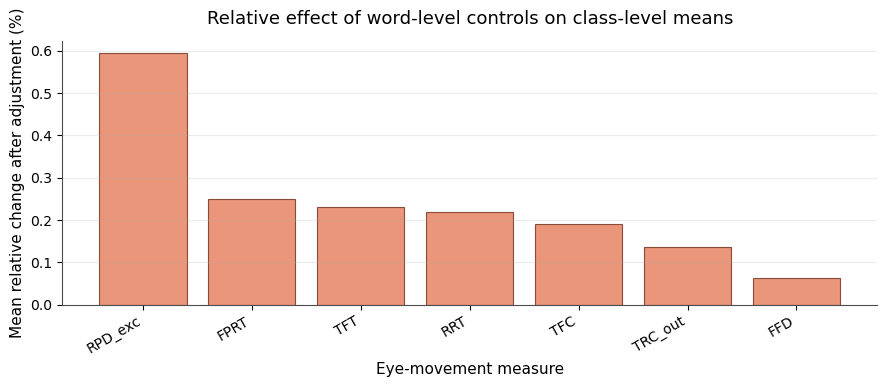

In [244]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4), facecolor="white")
ax.set_facecolor("white")

bar_color = "#E9967A"

ax.bar(
    mean_relative_change.index,
    mean_relative_change.values,
    color=bar_color,
    edgecolor="#8A4B3A",
    linewidth=0.8
)

ax.set_ylabel("Mean relative change after adjustment (%)")
ax.set_xlabel("Eye-movement measure")
ax.set_title("Relative effect of word-level controls on class-level means", pad=12)

ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_ha("right")

ax.grid(axis="y", alpha=0.25, linewidth=0.8)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("0.3")
ax.spines["bottom"].set_color("0.3")

plt.tight_layout()

plt.savefig(
    output_dir / "figure1_relative_adjustment_effect_by_measure.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# Statistical comparison of reading classes



In [245]:
from scipy.stats import kruskal
import pandas as pd


# Aggregate raw measures at reader-text level
# Each row = one reader-text-reading_class average
raw_reader_text = (
    analysis_df
    .groupby(["reader_id", "text_id", "reading_class"], observed=True)[measures]
    .mean()
    .reset_index()
)

def kruskal_by_class(df, measure_col, class_col="reading_class"):
    groups = []

    for cls in class_order:
        values = df.loc[df[class_col] == cls, measure_col].dropna()
        groups.append(values)

    stat, p_value = kruskal(*groups)
    return stat, p_value

kw_rows = []

for measure in measures:
    stat, p_value = kruskal_by_class(raw_reader_text, measure)

    kw_rows.append({
        "Measure": measure,
        "Kruskal H": stat,
        "p-value": p_value
    })

kw_table = pd.DataFrame(kw_rows)

# Display formatting
kw_table_display = kw_table.copy()

kw_table_display["Kruskal H"] = kw_table_display["Kruskal H"].map(
    lambda x: f"{x:.2f}"
)

kw_table_display["p-value"] = kw_table_display["p-value"].map(
    lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
)


kw_table_display

,Measure,Kruskal H,p-value
0,FFD,7.46,0.059
1,FPRT,17.37,<0.001
2,TFT,42.81,<0.001
3,TFC,41.38,<0.001
4,RRT,37.12,<0.001
5,RPD_exc,34.06,<0.001
6,TRC_out,13.41,0.004


In [246]:
from scipy.stats import wilcoxon, mannwhitneyu
from itertools import combinations
import pandas as pd


# All pairwise comparisons between the four reading classes
all_comparisons = list(combinations(class_order, 2))

# Aggregate raw measures at reader-class level
# Each reader contributes one mean per reading class
raw_reader_class = (
    analysis_df
    .groupby(["reader_id", "reading_class"], observed=True)[measures]
    .mean()
    .reset_index()
)

comparison_tables = {}

for class_a, class_b in all_comparisons:
    rows = []

    for measure in measures:
        df_a = (
            raw_reader_class[raw_reader_class["reading_class"] == class_a]
            [["reader_id", measure]]
            .dropna()
            .copy()
        )

        df_b = (
            raw_reader_class[raw_reader_class["reading_class"] == class_b]
            [["reader_id", measure]]
            .dropna()
            .copy()
        )

        readers_a = set(df_a["reader_id"])
        readers_b = set(df_b["reader_id"])

        # Paired test if both classes contain the same readers
        if readers_a == readers_b:
            paired_df = df_a.merge(
                df_b,
                on="reader_id",
                suffixes=("_A", "_B")
            )

            values_a = paired_df[f"{measure}_A"]
            values_b = paired_df[f"{measure}_B"]

            stat, p_value = wilcoxon(values_a, values_b)
            test_name = "Wilcoxon signed-rank"

        # Independent test otherwise
        else:
            values_a = df_a[measure]
            values_b = df_b[measure]

            stat, p_value = mannwhitneyu(
                values_a,
                values_b,
                alternative="two-sided"
            )

            test_name = "Mann-Whitney U"

        rows.append({
            "Measure": measure,
            "Test": test_name,
            "Mean A": values_a.mean(),
            "Mean B": values_b.mean(),
            "Difference A-B": values_a.mean() - values_b.mean(),
            "p-value": p_value
        })

    table = pd.DataFrame(rows)

    # Keep only useful columns
    table = table[
        [
            "Measure",
            "Test",
            "Mean A",
            "Mean B",
            "Difference A-B",
            "p-value"
        ]
    ]

    # Formatting:
    # means and differences = 2 decimals
    # p-values = 3 decimals, except very small p-values shown as <0.001
    table_display = table.copy()

    for col in ["Mean A", "Mean B", "Difference A-B"]:
        table_display[col] = table_display[col].map(lambda x: f"{x:.2f}")

    table_display["p-value"] = table_display["p-value"].map(
        lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
    )

    comparison_name = f"{class_a} vs {class_b}"
    comparison_tables[comparison_name] = table_display

    # Save each comparison table
    safe_name = (
        comparison_name
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )



Targeted class comparisons

In [247]:
for name, table in comparison_tables.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    display(table)


Expert vs Graduate out-of-domain


,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Wilcoxon signed-rank,164.87,170.05,-5.18,<0.001
1,FPRT,Wilcoxon signed-rank,238.32,259.54,-21.22,<0.001
2,TFT,Wilcoxon signed-rank,566.52,695.90,-129.38,<0.001
3,TFC,Wilcoxon signed-rank,2.54,3.06,-0.52,<0.001
4,RRT,Wilcoxon signed-rank,328.19,436.36,-108.17,<0.001
5,RPD_exc,Wilcoxon signed-rank,288.76,389.48,-100.72,<0.001
6,TRC_out,Wilcoxon signed-rank,0.38,0.44,-0.06,0.006



Expert vs Undergraduate in-domain


,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Mann-Whitney U,164.87,164.34,0.53,0.747
1,FPRT,Mann-Whitney U,238.32,241.00,-2.67,0.978
2,TFT,Mann-Whitney U,566.52,606.38,-39.86,0.446
3,TFC,Mann-Whitney U,2.54,2.78,-0.24,0.283
4,RRT,Mann-Whitney U,328.19,365.38,-37.19,0.421
5,RPD_exc,Mann-Whitney U,288.76,324.16,-35.39,0.402
6,TRC_out,Mann-Whitney U,0.38,0.42,-0.03,0.822



Expert vs Undergraduate out-of-domain


...

,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Mann-Whitney U,170.05,164.34,5.71,0.206
1,FPRT,Mann-Whitney U,259.54,241.00,18.54,0.159
2,TFT,Mann-Whitney U,695.90,606.38,89.52,0.144
3,TFC,Mann-Whitney U,3.06,2.78,0.28,0.180
4,RRT,Mann-Whitney U,436.36,365.38,70.98,0.210
5,RPD_exc,Mann-Whitney U,389.48,324.16,65.32,0.257
6,TRC_out,Mann-Whitney U,0.44,0.42,0.02,0.372



Graduate out-of-domain vs Undergraduate out-of-domain


,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Mann-Whitney U,170.05,165.03,5.01,0.338
1,FPRT,Mann-Whitney U,259.54,247.00,12.54,0.355
2,TFT,Mann-Whitney U,695.90,664.53,31.37,1.000
3,TFC,Mann-Whitney U,3.06,3.03,0.04,0.943
4,RRT,Mann-Whitney U,436.36,417.53,18.83,0.900
5,RPD_exc,Mann-Whitney U,389.48,371.32,18.16,0.857
6,TRC_out,Mann-Whitney U,0.44,0.46,-0.02,0.848



Undergraduate in-domain vs Undergraduate out-of-domain


,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Wilcoxon signed-rank,164.34,165.03,-0.70,0.695
1,FPRT,Wilcoxon signed-rank,241.00,247.00,-6.00,0.465
2,TFT,Wilcoxon signed-rank,606.38,664.53,-58.15,0.020
3,TFC,Wilcoxon signed-rank,2.78,3.03,-0.25,0.032
4,RRT,Wilcoxon signed-rank,365.38,417.53,-52.15,0.022
5,RPD_exc,Wilcoxon signed-rank,324.16,371.32,-47.16,0.019
6,TRC_out,Wilcoxon signed-rank,0.42,0.46,-0.05,0.056


# Expert Words Analysis

In [248]:


# Mean eye-movement measures on expert technical words only
expert_words_means = (
    expert_words_df
    .groupby("reading_class", observed=True)[measures]
    .mean()
    .reindex(class_order)
)

# Rename columns with units
measure_labels_with_units = {
    "FFD": "FFD (ms)",
    "FPRT": "FPRT (ms)",
    "TFT": "TFT (ms)",
    "TFC": "TFC (count)",
    "RRT": "RRT (ms)",
    "RPD_exc": "RPD_exc (ms)",
    "TRC_out": "TRC_out (count)"
}

table_expert_words_means = (
    expert_words_means
    .rename(columns=measure_labels_with_units)
    .round(1)
)


table_expert_words_means

,FFD (ms),FPRT (ms),TFT (ms),TFC (count),RRT (ms),RPD_exc (ms),TRC_out (count)
reading_class,,,,,,,
Expert,209.3,508.2,1185.0,5.1,676.9,428.2,0.6
Graduate out-of-domain,215.1,645.9,1699.7,7.0,1053.8,518.4,0.7
Undergraduate in-domain,208.5,564.3,1414.0,6.2,849.7,344.3,0.7
Undergraduate out-of-domain,210.7,624.5,1622.3,6.8,997.8,640.0,0.7


In [249]:
from scipy.stats import kruskal
import pandas as pd

# Aggregate expert technical words at reader-class level
expert_words_reader_class = (
    expert_words_df
    .groupby(["reader_id", "reading_class"], observed=True)[measures]
    .mean()
    .reset_index()
)

expert_word_kw_rows = []

for measure in measures:
    groups = []

    for cls in class_order:
        values = expert_words_reader_class.loc[
            expert_words_reader_class["reading_class"] == cls,
            measure
        ].dropna()

        groups.append(values)

    stat, p_value = kruskal(*groups)

    expert_word_kw_rows.append({
        "Measure": measure,
        "Kruskal H": stat,
        "p-value": p_value
    })

table_expert_words_kw = pd.DataFrame(expert_word_kw_rows)

# Display formatting
table_expert_words_kw_display = table_expert_words_kw.copy()

table_expert_words_kw_display["Kruskal H"] = (
    table_expert_words_kw_display["Kruskal H"]
    .map(lambda x: f"{x:.2f}")
)

table_expert_words_kw_display["p-value"] = (
    table_expert_words_kw_display["p-value"]
    .map(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
)


table_expert_words_kw_display

,Measure,Kruskal H,p-value
0,FFD,0.71,0.871
1,FPRT,11.92,0.008
2,TFT,15.70,0.001
3,TFC,16.82,<0.001
4,RRT,13.47,0.004
5,RPD_exc,2.85,0.415
6,TRC_out,1.39,0.707


In [250]:
from scipy.stats import wilcoxon, mannwhitneyu
from itertools import combinations
import pandas as pd

# All pairwise comparisons between the four reading classes
all_comparisons = list(combinations(class_order, 2))

expert_word_comparison_tables = {}

for class_a, class_b in all_comparisons:
    rows = []

    for measure in measures:
        df_a = (
            expert_words_reader_class[
                expert_words_reader_class["reading_class"] == class_a
            ][["reader_id", measure]]
            .dropna()
            .copy()
        )

        df_b = (
            expert_words_reader_class[
                expert_words_reader_class["reading_class"] == class_b
            ][["reader_id", measure]]
            .dropna()
            .copy()
        )

        readers_a = set(df_a["reader_id"])
        readers_b = set(df_b["reader_id"])

        # Paired test if both classes contain the same readers
        if readers_a == readers_b:
            paired_df = df_a.merge(
                df_b,
                on="reader_id",
                suffixes=("_A", "_B")
            )

            values_a = paired_df[f"{measure}_A"]
            values_b = paired_df[f"{measure}_B"]

            stat, p_value = wilcoxon(values_a, values_b)
            test_name = "Wilcoxon signed-rank"

        # Independent test otherwise
        else:
            values_a = df_a[measure]
            values_b = df_b[measure]

            stat, p_value = mannwhitneyu(
                values_a,
                values_b,
                alternative="two-sided"
            )

            test_name = "Mann-Whitney U"

        rows.append({
            "Measure": measure,
            "Test": test_name,
            "Mean A": values_a.mean(),
            "Mean B": values_b.mean(),
            "Difference A-B": values_a.mean() - values_b.mean(),
            "p-value": p_value
        })

    table = pd.DataFrame(rows)

    table = table[
        [
            "Measure",
            "Test",
            "Mean A",
            "Mean B",
            "Difference A-B",
            "p-value"
        ]
    ]

    # Formatting
    table_display = table.copy()

    for col in ["Mean A", "Mean B", "Difference A-B"]:
        table_display[col] = table_display[col].map(lambda x: f"{x:.2f}")

    table_display["p-value"] = table_display["p-value"].map(
        lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
    )

    comparison_name = f"{class_a} vs {class_b}"
    expert_word_comparison_tables[comparison_name] = table_display

    # Save each comparison table
    safe_name = (
        comparison_name
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )



In [251]:
for comparison_name, table in expert_word_comparison_tables.items():
    print("\n" + "=" * 80)
    print(comparison_name)
    print("=" * 80)
    display(table)


Expert vs Graduate out-of-domain


,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Wilcoxon signed-rank,209.12,214.66,-5.54,0.038
1,FPRT,Wilcoxon signed-rank,502.34,631.08,-128.74,<0.001
2,TFT,Wilcoxon signed-rank,1190.96,1653.00,-462.05,<0.001
3,TFC,Wilcoxon signed-rank,5.12,6.81,-1.69,<0.001
4,RRT,Wilcoxon signed-rank,688.62,1021.92,-333.30,<0.001
5,RPD_exc,Wilcoxon signed-rank,467.08,556.98,-89.90,0.611
6,TRC_out,Wilcoxon signed-rank,0.63,0.70,-0.07,0.169



Expert vs Undergraduate in-domain


,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Mann-Whitney U,209.12,208.03,1.09,0.657
1,FPRT,Mann-Whitney U,502.34,559.73,-57.39,0.226
2,TFT,Mann-Whitney U,1190.96,1406.17,-215.21,0.102
3,TFC,Mann-Whitney U,5.12,6.10,-0.98,0.070
4,RRT,Mann-Whitney U,688.62,846.44,-157.82,0.176
5,RPD_exc,Mann-Whitney U,467.08,369.12,97.97,0.697
6,TRC_out,Mann-Whitney U,0.63,0.67,-0.05,0.801



Expert vs Undergraduate out-of-domain


...

,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Mann-Whitney U,214.66,208.03,6.63,0.446
1,FPRT,Mann-Whitney U,631.08,559.73,71.35,0.116
2,TFT,Mann-Whitney U,1653.00,1406.17,246.83,0.156
3,TFC,Mann-Whitney U,6.81,6.10,0.71,0.187
4,RRT,Mann-Whitney U,1021.92,846.44,175.48,0.210
5,RPD_exc,Mann-Whitney U,556.98,369.12,187.87,0.235
6,TRC_out,Mann-Whitney U,0.70,0.67,0.03,0.665



Graduate out-of-domain vs Undergraduate out-of-domain


,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Mann-Whitney U,214.66,209.70,4.97,0.611
1,FPRT,Mann-Whitney U,631.08,605.75,25.33,0.551
2,TFT,Mann-Whitney U,1653.00,1593.55,59.46,0.805
3,TFC,Mann-Whitney U,6.81,6.76,0.05,0.780
4,RRT,Mann-Whitney U,1021.92,987.80,34.12,0.706
5,RPD_exc,Mann-Whitney U,556.98,686.16,-129.18,0.595
6,TRC_out,Mann-Whitney U,0.70,0.75,-0.05,0.780



Undergraduate in-domain vs Undergraduate out-of-domain


,Measure,Test,Mean A,Mean B,Difference A-B,p-value
0,FFD,Wilcoxon signed-rank,208.03,209.70,-1.67,0.937
1,FPRT,Wilcoxon signed-rank,559.73,605.75,-46.02,0.451
2,TFT,Wilcoxon signed-rank,1406.17,1593.55,-187.38,0.077
3,TFC,Wilcoxon signed-rank,6.10,6.76,-0.65,0.104
4,RRT,Wilcoxon signed-rank,846.44,987.80,-141.36,0.040
5,RPD_exc,Wilcoxon signed-rank,369.12,686.16,-317.04,0.099
6,TRC_out,Wilcoxon signed-rank,0.67,0.75,-0.08,0.227


# Prediction Measures to Class

In [252]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# Build one observation per reader-text pair.
# Each row contains the mean eye-movement measures for one reader reading one text.
prediction_df = (
    analysis_df
    .groupby(
        [
            "reader_id",
            "text_id",
            "reading_class",
            "reader_discipline_numeric",
            "level_of_studies_numeric",
            "text_domain_numeric"
        ],
        observed=True
    )[measures]
    .mean()
    .reset_index()
)

# Prediction target 1: the full four-class reading label
prediction_df["target_reading_class"] = prediction_df["reading_class"].astype(str)

# Prediction target 2: whether the text is in-domain or out-of-domain
prediction_df["target_domain_match"] = np.where(
    prediction_df["reader_discipline_numeric"] == prediction_df["text_domain_numeric"],
    "In-domain",
    "Out-of-domain"
)

# Prediction target 3: whether the reader is graduate or undergraduate
prediction_df["target_academic_level"] = np.where(
    prediction_df["level_of_studies_numeric"] == 1,
    "Graduate",
    "Undergraduate"
)

print("Prediction dataframe shape:", prediction_df.shape)

prediction_df[
    [
        "reader_id",
        "text_id",
        "reading_class",
        "target_domain_match",
        "target_academic_level",
        "target_reading_class"
    ]
].head()

Prediction dataframe shape: (900, 16)


,reader_id,text_id,reading_class,target_domain_match,target_academic_level,target_reading_class
0,0,b0,Graduate out-of-domain,Out-of-domain,Graduate,Graduate out-of-domain
1,0,b1,Graduate out-of-domain,Out-of-domain,Graduate,Graduate out-of-domain
2,0,b2,Graduate out-of-domain,Out-of-domain,Graduate,Graduate out-of-domain
3,0,b3,Graduate out-of-domain,Out-of-domain,Graduate,Graduate out-of-domain
4,0,b4,Graduate out-of-domain,Out-of-domain,Graduate,Graduate out-of-domain


In [253]:
# We compare logistic regression to a simple majority-class baseline.
# Logistic regression is useful because it gives both prediction scores and interpretable coefficients.
models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),

    "Logistic regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])
}

# We use balanced accuracy and macro-F1 because some classes are not equally represented.
scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro"
}

# GroupKFold keeps all observations from the same reader in the same fold.
# This prevents the same reader from appearing in both training and test data.
cv = GroupKFold(n_splits=5)


def evaluate_prediction_task(df, target_col, task_name):
    """
    Evaluate baseline and logistic regression for one prediction task.
    """
    X = df[measures].copy()
    y = df[target_col].copy()
    groups = df["reader_id"].copy()

    rows = []

    for model_name, model in models.items():
        scores = cross_validate(
            model,
            X,
            y,
            groups=groups,
            cv=cv,
            scoring=scoring
        )

        rows.append({
            "Task": task_name,
            "Model": model_name,
            "Balanced accuracy": scores["test_balanced_accuracy"].mean(),
            "Macro-F1": scores["test_macro_f1"].mean()
        })

    return pd.DataFrame(rows)

In [254]:
# Evaluate the three prediction tasks:
# 1. Domain match
# 2. Academic level
# 3. Full four-class reading label
prediction_results_report = pd.concat(
    [
        evaluate_prediction_task(
            prediction_df,
            target_col="target_domain_match",
            task_name="Domain match"
        ),
        evaluate_prediction_task(
            prediction_df,
            target_col="target_academic_level",
            task_name="Academic level"
        ),
        evaluate_prediction_task(
            prediction_df,
            target_col="target_reading_class",
            task_name="Four-class reading class"
        )
    ],
    ignore_index=True
)

# Round scores for the report table
prediction_results_report[["Balanced accuracy", "Macro-F1"]] = (
    prediction_results_report[["Balanced accuracy", "Macro-F1"]]
    .round(2)
)

prediction_results_report

,Task,Model,Balanced accuracy,Macro-F1
0,Domain match,Baseline,0.50,0.33
1,Domain match,Logistic regression,0.61,0.61
2,Academic level,Baseline,0.50,0.38
3,Academic level,Logistic regression,0.49,0.48
4,Four-class reading class,Baseline,0.25,0.12
5,Four-class reading class,Logistic regression,0.30,0.30


In [255]:
def collect_logistic_coefficients(df, target_col, target_positive_label):
    """
    Fit logistic regression across GroupKFold splits and collect coefficients.

    For binary tasks, sklearn stores coefficients for classes_[1].
    If classes_[1] is not the label we want to interpret as positive,
    we reverse the sign of the coefficients.
    """
    X = df[measures].copy()
    y = df[target_col].copy()
    groups = df["reader_id"].copy()

    fold_rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs"
            ))
        ])

        model.fit(X_train, y_train)

        clf = model.named_steps["clf"]
        coef_values = clf.coef_[0]

        # Make coefficients correspond to the chosen positive class.
        if clf.classes_[1] != target_positive_label:
            coef_values = -coef_values

        for measure, coef in zip(measures, coef_values):
            fold_rows.append({
                "Fold": fold_idx,
                "Measure": measure,
                "Coefficient": coef
            })

    coef_folds = pd.DataFrame(fold_rows)

    # Average coefficients across folds
    coef_summary = (
        coef_folds
        .groupby("Measure")
        .agg(
            mean_coef=("Coefficient", "mean"),
            std_coef=("Coefficient", "std"),
            n_folds=("Coefficient", "size")
        )
        .reset_index()
    )

    # 95% confidence interval across folds
    coef_summary["ci95"] = (
        1.96 * coef_summary["std_coef"] / np.sqrt(coef_summary["n_folds"])
    )

    # Keep the same order as the measure list
    coef_summary["Measure"] = pd.Categorical(
        coef_summary["Measure"],
        categories=measures,
        ordered=True
    )

    return coef_summary.sort_values("Measure")


# Coefficients for domain prediction:
# positive = Out-of-domain
domain_coef_summary = collect_logistic_coefficients(
    prediction_df,
    target_col="target_domain_match",
    target_positive_label="Out-of-domain"
)

# Coefficients for academic-level prediction:
# positive = Graduate
level_coef_summary = collect_logistic_coefficients(
    prediction_df,
    target_col="target_academic_level",
    target_positive_label="Graduate"
)

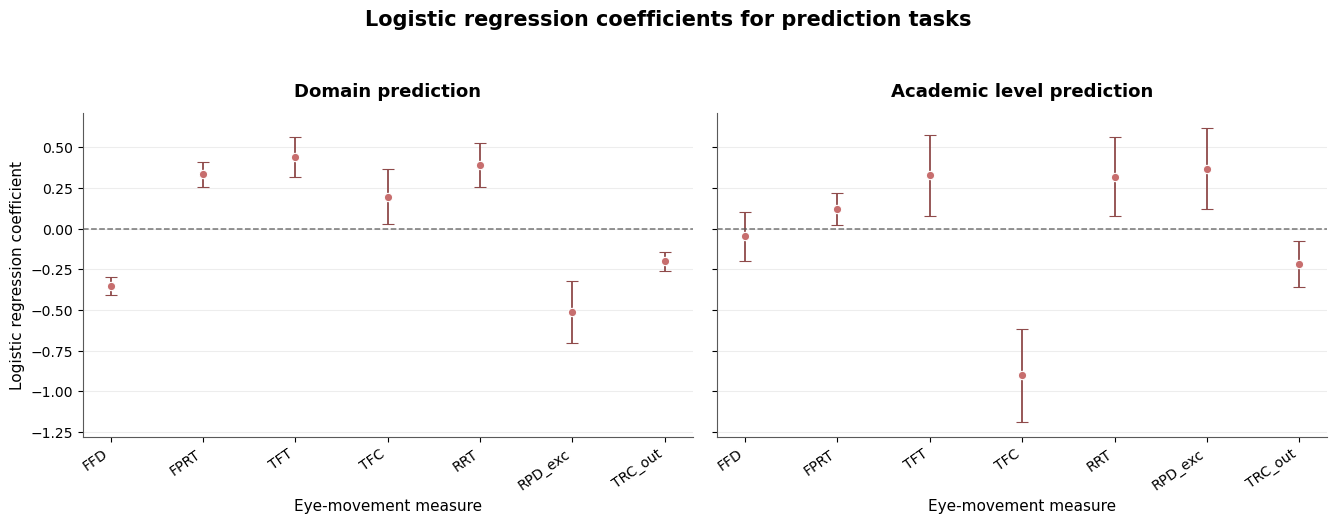

In [256]:
import matplotlib.pyplot as plt

# Clean plotting style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.edgecolor": "0.25",
    "axes.linewidth": 0.8
})

fig, axes = plt.subplots(
    1, 2,
    figsize=(13.5, 5),
    sharey=True,
    facecolor="white"
)

plot_specs = [
    (axes[0], domain_coef_summary, "Domain prediction"),
    (axes[1], level_coef_summary, "Academic level prediction")
]

point_color = "#C76E6E"
error_color = "#8F4A4A"
zero_color = "#555555"

for ax, coef_summary, title in plot_specs:
    x = np.arange(len(measures))

    # Plot mean logistic regression coefficients with 95% CI across folds
    ax.errorbar(
        x,
        coef_summary["mean_coef"],
        yerr=coef_summary["ci95"],
        fmt="o",
        markersize=6,
        capsize=4,
        capthick=1.2,
        elinewidth=1.3,
        color=point_color,
        ecolor=error_color,
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=0
    )

    # Zero line: positive and negative coefficients are interpreted relative to this line
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.1,
        color=zero_color,
        alpha=0.8
    )

    ax.set_xticks(x)
    ax.set_xticklabels(measures, rotation=35, ha="right")

    ax.set_title(title, pad=12, fontweight="bold")
    ax.set_xlabel("Eye-movement measure")

    ax.grid(axis="y", alpha=0.22, linewidth=0.8)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("0.35")
    ax.spines["bottom"].set_color("0.35")

axes[0].set_ylabel("Logistic regression coefficient")

fig.suptitle(
    "Logistic regression coefficients for prediction tasks",
    fontsize=15,
    fontweight="bold",
    y=1.04
)

plt.tight_layout()


plt.show()